### Packages

In [1]:
import sys
print(sys.executable)

/Users/russellwhealdon/mmm-workspace/.venv/bin/python


In [2]:
# ── Environment ──────────────────────────────────────────────────────────────
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU

# ── Core libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az
tfd = tfp.distributions

# ── Meridian ──────────────────────────────────────────────────────────────────
import meridian
from meridian import constants
from meridian.analysis import analyzer, optimizer, summarizer, visualizer
from meridian.analysis.review import reviewer
from meridian.data import data_frame_input_data_builder
from meridian.model import model, prior_distribution, spec, transformers

print(f"Meridian {meridian.__version__} ready")
print(f"TF devices: {tf.config.list_physical_devices()}")

### Load Data from Files

In [3]:
#raw_data = pd.read_csv("NS_mmm_data_wOrganic.csv")
raw_data = pd.read_csv("/Users/russellwhealdon/mmm-workspace/data/raw/northspore/NS_mmm_data_Mar26.csv")

In [5]:
raw_data.head()

,date,geo,DVD_Cost,Retargeting_Cost,Shopping_Cost,Prospecting_Cost,Remarketing_Cost,Brand_Cost,Non_Brand_Cost,DVD_Impressions,...,population,Amazon_Cost,Amazon_Impressions,Facebook_Views,Instagram_Views,YouTube_Views,Promo Intensity,Product Launch,weekly_average_temp,weekly_rainfall
0,2024-01-01,AK,7.022993,17.694355,14.75,65.032256,0.0,5.40,88.71,282,...,750000,0.0,0.0,0.0,0.0,0.0,0.2,0.0,17.431020,0.379921
1,2024-01-08,AK,3.164727,16.395904,44.81,60.292926,0.0,5.51,66.60,209,...,750000,0.0,0.0,0.0,0.0,0.0,0.2,0.0,16.020408,0.330217
2,2024-01-15,AK,9.586830,16.064609,23.62,68.541314,0.0,16.71,75.61,790,...,750000,0.0,0.0,0.0,0.0,0.0,0.2,0.0,9.716735,0.632382
3,2024-01-22,AK,10.641802,19.754004,21.61,74.123413,0.0,13.37,88.90,761,...,750000,0.0,0.0,0.0,0.0,0.0,0.2,0.0,-10.149388,0.514483
4,2024-01-29,AK,9.629326,20.485583,65.43,70.342600,0.0,40.19,50.31,436,...,750000,0.0,0.0,0.0,0.0,0.0,0.2,0.0,-3.921633,0.875141


### Ensure we have rows for all dates/geos

In [4]:
start_date = pd.to_datetime("2024-03-01")
end_date = pd.to_datetime("2026-03-31")
raw_data['date'] = pd.to_datetime(raw_data['date']) # Convert 'date' column to datetime objects
raw_data = raw_data[(raw_data['date'] >= start_date) & (raw_data['date'] <= end_date)].copy()

In [5]:
# 1. Ensure 'date' is a proper datetime object
raw_data['date'] = pd.to_datetime(raw_data['date'])

# 2. Get the unique list of all dates and all geos
all_dates = raw_data['date'].unique()
all_geos = raw_data['geo'].unique()

# 3. Create a 'Perfect Index' of all possible combinations
perfect_index = pd.MultiIndex.from_product(
    [all_dates, all_geos],
    names=['date', 'geo']
)
perfect_df = pd.DataFrame(index=perfect_index).reset_index()

# 4. Merge your data into the perfect structure
# Use 'left' join so we keep every date/geo combo, filling missing with 0
raw_data = pd.merge(perfect_df, raw_data, on=['date', 'geo'], how='left').fillna(0)

# 5. Sort to ensure alignment (VERY important for Meridian)
raw_data = raw_data.sort_values(['geo', 'date']).reset_index(drop=True)

print(f"Data Re-aligned! Total rows should be {len(all_dates) * len(all_geos)}.")
print(f"Current rows: {len(raw_data)}")

Data Re-aligned! Total rows should be 5559.
Current rows: 5559


### Fix Black Friday Dates

In [6]:
raw_data["date"] = pd.to_datetime(raw_data["date"])

# Week bucket (Monday-start week). This is the time index Meridian effectively uses.
raw_data["week_start"] = raw_data["date"] - pd.to_timedelta(raw_data["date"].dt.weekday, unit="D")

def black_friday_date(year: int) -> pd.Timestamp:
    nov1 = pd.Timestamp(year=year, month=11, day=1)
    first_thu = nov1 + pd.Timedelta(days=(3 - nov1.weekday()) % 7)
    fourth_thu = first_thu + pd.Timedelta(days=21)
    return fourth_thu + pd.Timedelta(days=1)

bf_dates = [black_friday_date(y) for y in raw_data["date"].dt.year.unique()]
bf_week_starts = [(bf - pd.Timedelta(days=bf.weekday())) for bf in bf_dates]  # Monday of BF week

raw_data["black_friday"] = raw_data["week_start"].isin(bf_week_starts).astype(np.int32)

# Sanity check: should be 1 for exactly ~1 week per year (per geo)
print(raw_data.groupby("date")["black_friday"].max().value_counts())
print("BF weeks:", raw_data.loc[raw_data["black_friday"] == 1, "date"].sort_values().unique()[:10])

black_friday
0    107
1      2
Name: count, dtype: int64
BF weeks: <DatetimeArray>
['2024-11-25 00:00:00', '2025-11-24 00:00:00']
Length: 2, dtype: datetime64[ns]


### Build Priors

In [7]:
raw_data.columns

Index(['date', 'geo', 'DVD_Cost', 'Retargeting_Cost', 'Shopping_Cost',
       'Prospecting_Cost', 'Remarketing_Cost', 'Brand_Cost', 'Non_Brand_Cost',
       'DVD_Impressions', 'Retargeting_Impressions', 'Shopping_Impressions',
       'Prospecting_Impressions', 'Remarketing_Impressions',
       'Brand_Impressions', 'Non_Brand_Impressions', 'Purchases', 'Revenue',
       'bf_date', 'population', 'Amazon_Cost', 'Amazon_Impressions',
       'Facebook_Views', 'Instagram_Views', 'YouTube_Views', 'Promo Intensity',
       'Product Launch', 'weekly_average_temp', 'weekly_rainfall',
       'week_start', 'black_friday'],
      dtype='object')

In [8]:
# ==========================================================
# 1) CHANNELS + TYPE CASTING (NO MANUAL SCALING)
# ==========================================================
channels = ["Brand", "Non_Brand", "DVD", "Retargeting", "Prospecting", "Shopping", "Amazon"]

# KPI
raw_data["Revenue"] = raw_data["Revenue"].astype(np.float32)

# Media
for c in channels:
    raw_data[f"{c}_Cost"] = raw_data[f"{c}_Cost"].astype(np.float32)
    raw_data[f"{c}_Impressions"] = raw_data[f"{c}_Impressions"].astype(np.float32)

# Population
raw_data["population"] = raw_data["population"].astype(np.float32)

# Controls
raw_data["Promo Intensity"] = raw_data["Promo Intensity"].astype(np.float32)
raw_data["weekly_average_temp"] = raw_data["weekly_average_temp"].astype(np.float32)

In [9]:
# ==========================================================
# 2) INPUT DATA BUILDER
# ==========================================================

# Define your organic channels separately from paid channels
organic_channels = ['Facebook', 'Instagram', 'YouTube']  # adjust to your actual channel names

builder = data_frame_input_data_builder.DataFrameInputDataBuilder(kpi_type="revenue")
builder = builder.with_kpi(
    raw_data,
    kpi_col="Revenue",
    time_col="date",
    geo_col="geo",
)
builder = builder.with_media(
    raw_data,
    media_channels=channels,
    media_spend_cols=[f"{c}_Cost" for c in channels],
    media_cols=[f"{c}_Impressions" for c in channels],
    time_col="date",
    geo_col="geo",
)

# ✅ ADD ORGANIC MEDIA — no spend cols, impressions/clicks only
builder = builder.with_organic_media(
    raw_data,
    organic_media_cols=[f"{c}_Views" for c in organic_channels],
    organic_media_channels=organic_channels,
    media_time_col="date",
    geo_col="geo",
)

builder = builder.with_controls(
    raw_data,
    control_cols=["black_friday", "Promo Intensity", "weekly_average_temp"],
    time_col="date",
    geo_col="geo",
)
builder = builder.with_population(
    raw_data,
    population_col="population",
    geo_col="geo",
)
input_data = builder.build()

/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/data/input_data.py:517: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


In [10]:
# ==========================================================
# 3) ROI PRIOR STRATEGY — channel-specific ranges via lognormal_dist_from_range
# ==========================================================
# Each range represents the 95% credible interval for that channel's ROI.
# Ranges are informed by industry benchmarks and holdout test evidence.
#
# Prospecting uses a deliberately wider/lower range (0.8–6.0x):
#   - Holdout test showed low incremental impact in that period
#   - Seasonal variation means true ROI may be higher at other times of year
#   - Wide range reflects genuine uncertainty across seasons
#
# Channel order must match the `channels` list defined earlier:
#   ["Brand", "Non_Brand", "DVD", "Retargeting", "Prospecting", "Shopping", "Amazon"]

roi_ranges = {
    "Brand":       (1.3, 10.6),
    "Non_Brand":   (1.8,  7.7),
    "DVD":         (1.3, 12.3),
    "Retargeting": (1.3, 12.4),
    "Prospecting": (0.8,  6.0),  # wider — holdout evidence + seasonal uncertainty
    "Shopping":    (2.0,  7.9),
    "Amazon":      (1.2,  4.9),
}

# Build per-channel LogNormal distributions from (low, high) 95% mass intervals
roi_dists = [
    prior_distribution.lognormal_dist_from_range(
        low=roi_ranges[c][0],
        high=roi_ranges[c][1],
        mass_percent=0.95,
    )
    for c in channels
]

# Stack individual distributions into a single batched LogNormal for PriorDistribution
roi_loc_vec   = tf.cast([d.loc   for d in roi_dists], tf.float32)
roi_scale_vec = tf.cast([d.scale for d in roi_dists], tf.float32)

my_priors = prior_distribution.PriorDistribution(
    roi_m=tfd.LogNormal(
        loc=roi_loc_vec,
        scale=roi_scale_vec,
    )
)

# Optional: if your holdout window is inside your MMM window AND you want to restrict
# the ROI calibration to that window, Meridian supports roi_calibration_period in ModelSpec.
# We'll leave it off for v1 and add later if needed.
# roi_calibration_period = ("2025-09-08", "2025-09-29")  # example Monday-week bounds

#### ROI Strategy with no custom for Prospecting

In [11]:
# # ==========================================================
# # 3) ROI PRIOR STRATEGY (UNIFORM ACROSS CHANNELS)
# # ==========================================================

# # Set one ROI mean for all channels
# roi_mean = 4.0   # <-- choose your desired prior mean ROI
# roi_scale = 0.6  # <-- prior uncertainty (0.4–0.8 typical range)

# # Convert to log space (LogNormal is parameterized in log space)
# roi_loc = np.log(roi_mean)

# # Create equal-length vectors for all channels
# roi_loc_vector = [roi_loc] * len(channels)
# roi_scale_vector = [roi_scale] * len(channels)

# my_priors = prior_distribution.PriorDistribution(
#     roi_m=tfd.LogNormal(
#         loc=tf.cast(roi_loc_vector, tf.float32),
#         scale=tf.cast(roi_scale_vector, tf.float32),
#     )
# )

#### Model Spec

In [12]:
# ==========================================================
# 4) MODEL SPEC & EXECUTION
# ==========================================================
n_weeks = raw_data["date"].nunique()

model_spec = spec.ModelSpec(
    prior=my_priors,
    media_prior_type="roi",

    # Time representation (disciplined baseline)
    knots=26,
    #enable_aks=True,

    # Media transformation choices we agreed on
    max_lag=6,
    adstock_decay_spec="geometric",

    # Typical default
    media_effects_dist="log_normal",

    # If you later want: roi_calibration_period=roi_calibration_period
)

mmm = model.Meridian(input_data=input_data, model_spec=model_spec)

2026-04-02 15:32:18.367672: I external/local_xla/xla/service/service.cc:163] XLA service 0x16fab88e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-02 15:32:18.367821: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1775169138.508322 29297804 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


### Run Model

In [14]:
# # Sample
# mmm.sample_prior(1000)
# mmm.sample_posterior(
#     n_chains=4,
#     n_adapt=1000,
#     n_burnin=1000,
#     n_keep=2000,
#     seed=42,
# )

/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [13]:
# DEV run — fast iteration (swap for production config when sending to Colab)
mmm.sample_prior(500)
mmm.sample_posterior(
    n_chains=1,
    n_adapt=200,
    n_burnin=200,
    n_keep=200,
    seed=42,
)

2026-04-02 15:33:01.539541: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-02 15:33:03.155663: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


### Review Model

In [14]:
reviewer.ModelReviewer(mmm).run()

/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/tensorflow_probability/python/mcmc/diagnostic.py:580: RuntimeWarning: divide by zero encountered in divide
  return (n / (n - 1.)) * biased_var
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:676: RuntimeWarning: divide by zero encountered in divide
  return backend.nanmean(backend.absolute((actual - expected) / actual))


Model Quality Checks
Overall Status: PASS
Summary: Passed with reviews: Review is needed.
Health Score: 98.1

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: PASS
  Recommendation: The posterior probability that the baseline is negative is 0.00. We recommend visually inspecting the baseline time series in the Model Fit charts to confirm this.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 0.98. The observed total outcome is consistent with the model's posterior predictive distribution.
----------------------------------------
GoodnessOfFit Check:
  Status: PASS
  Recommendation: R-squared = 0.6474, MAPE = inf, and wMAPE = 0.2253. These goodness-of-fit metrics are intended for guidance and relative 

### Core health check

**mean**: Posterior mean estimate of the parameter.

**sd**: Posterior standard deviation → uncertainty.

**hdi_3% / hdi_97%:** 94% highest-density interval (credible interval). This is your Bayesian “confidence interval.”

**mcse_mean / mcse_sd**: Monte Carlo standard error.
→ Should be small relative to sd.

**ess_bulk / ess_tail**: Effective sample size (bulk & tails).
→ Measures how well the chains mixed.

**r_hat**: Convergence diagnostic.
→ Should be very close to 1.0.

In [15]:
idata = mmm.inference_data

az.summary(
    idata,
    var_names=[
        "beta_m",
        "alpha_m",
        "ec_m",
        "sigma"
    ],
    round_to=3
)

arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_m[Brand],-2.836,0.877,-4.403,-1.218,0.109,0.077,63.308,130.384,NaN
beta_m[Non_Brand],-3.165,1.146,-5.476,-1.470,0.121,0.086,84.364,150.801,NaN
beta_m[DVD],-4.527,0.847,-6.084,-3.162,0.060,0.044,222.483,154.496,NaN
beta_m[Retargeting],-3.689,0.952,-5.604,-2.202,0.068,0.048,181.649,96.923,NaN
beta_m[Prospecting],-1.429,0.868,-2.937,-0.055,0.125,0.089,47.524,118.977,NaN
beta_m[Shopping],-1.171,0.699,-2.579,-0.142,0.074,0.054,95.647,152.814,NaN
beta_m[Amazon],-5.274,1.136,-7.227,-3.367,0.085,0.061,183.992,176.756,NaN
alpha_m[Brand],0.328,0.254,0.005,0.855,0.016,0.012,253.763,147.185,NaN
alpha_m[Non_Brand],0.522,0.326,0.012,0.970,0.032,0.023,107.260,94.211,NaN
alpha_m[DVD],0.482,0.290,0.029,0.931,0.014,0.010,460.206,217.056,NaN


### Core model-fit diagnostics

In [16]:
from meridian.analysis import analyzer

m_analyzer = analyzer.Analyzer(mmm)

# This returns posterior predictive summary metrics
summary_metrics = m_analyzer.summary_metrics(
    aggregate_geos=True,   # global
    use_kpi=True
)

summary_df = summary_metrics.to_dataframe().reset_index()
summary_df

/var/folders/0j/bpw9xk0962z96r8g37j1z3wm0000gn/T/ipykernel_48183/1547925055.py:3: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  m_analyzer = analyzer.Analyzer(mmm)
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:1031: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:1031: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(


,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,Brand,mean,prior,14468114.0,4.221934,3.578732e+05,8.01241,24.735302,1.559332e+06,2.421933,4.357221,0.107777,1.654076,0.309036
1,Brand,mean,posterior,14468114.0,4.221934,3.578732e+05,8.01241,24.735302,1.870477e+06,5.538490,5.226647,0.129283,2.149152,0.274611
2,Brand,median,prior,14468114.0,4.221934,3.578732e+05,8.01241,24.735302,1.299431e+06,2.018257,3.630982,0.089813,1.369445,0.275408
3,Brand,median,posterior,14468114.0,4.221934,3.578732e+05,8.01241,24.735302,1.501458e+06,4.445823,4.195504,0.103777,1.597109,0.238353
4,Brand,ci_lo,prior,14468114.0,4.221934,3.578732e+05,8.01241,24.735302,5.798179e+05,0.900565,1.620177,0.040076,0.526437,0.108050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,All Channels,median,posterior,342689248.0,100.000000,4.466486e+06,100.00000,13.033632,1.990742e+07,58.945923,4.457065,NaN,NaN,0.224364
60,All Channels,ci_lo,prior,342689248.0,100.000000,4.466486e+06,100.00000,13.033632,1.122286e+07,17.431189,2.512684,NaN,NaN,0.202505
61,All Channels,ci_lo,posterior,342689248.0,100.000000,4.466486e+06,100.00000,13.033632,1.452040e+07,42.994961,3.250968,NaN,NaN,0.169203
62,All Channels,ci_hi,prior,342689248.0,100.000000,4.466486e+06,100.00000,13.033632,2.205618e+07,34.257328,4.938150,NaN,NaN,0.397981


In [28]:
summary_df.tail(30)

,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
34,Prospecting,median,prior,137322496.0,40.072018,1.305988e+06,29.239735,9.510376,2.743254e+06,4.260780,2.100519,0.019977,0.940791,0.476073
35,Prospecting,median,posterior,137322496.0,40.072018,1.305988e+06,29.239735,9.510376,6.297539e+06,18.647034,4.822048,0.045859,3.151042,0.207382
36,Prospecting,ci_lo,prior,137322496.0,40.072018,1.305988e+06,29.239735,9.510376,1.165006e+06,1.809471,0.892049,0.008484,0.315654,0.198976
37,Prospecting,ci_lo,posterior,137322496.0,40.072018,1.305988e+06,29.239735,9.510376,2.900188e+06,8.587466,2.220684,0.021120,1.283106,0.119167
38,Prospecting,ci_hi,prior,137322496.0,40.072018,1.305988e+06,29.239735,9.510376,6.563541e+06,10.194395,5.025726,0.047797,2.713546,1.121016
39,Prospecting,ci_hi,posterior,137322496.0,40.072018,1.305988e+06,29.239735,9.510376,1.095935e+07,32.450665,8.391611,0.079807,6.154273,0.450325
40,Shopping,mean,prior,93738000.0,27.353645,1.199402e+06,26.853371,12.795258,5.198000e+06,8.073457,4.333826,0.055452,2.033328,0.262661
41,Shopping,mean,posterior,93738000.0,27.353645,1.199402e+06,26.853371,12.795258,6.255280e+06,18.521910,5.215336,0.066732,3.780012,0.213991
42,Shopping,median,prior,93738000.0,27.353645,1.199402e+06,26.853371,12.795258,4.821488e+06,7.488665,4.019911,0.051436,1.907430,0.248762
43,Shopping,median,posterior,93738000.0,27.353645,1.199402e+06,26.853371,12.795258,6.116101e+06,18.109797,5.099293,0.065247,3.642982,0.196106


### Model Output

In [17]:
from meridian.analysis import summarizer

# 1. Initialize the summarizer
summary = summarizer.Summarizer(mmm)

# 2. Get the core summary table
# This will show Spend, Incremental Leads, ROI, and mROI (Marginal ROI)
# roi_table = summary.kpi_summary_table()
# print(roi_table)

summary

In [18]:
# Plot the contribution pie chart using the summarizer object
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()

/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:1031: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/visualizer.py:1678: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,Brand,prior,"14,468,114",4%,"$357,873",8%,$25,"$1,559,332 ($579,818, $3,312,117)","2.4% (0.9%, 5.1%)","4.4 (1.6, 9.3)","0.11 (0.04, 0.23)","1.7 (0.5, 3.9)","$0.3 ($0.1, $0.6)"
1,Brand,posterior,"14,468,114",4%,"$357,873",8%,$25,"$1,870,477 ($620,078, $4,544,300)","5.5% (1.8%, 13.5%)","5.2 (1.7, 12.7)","0.13 (0.04, 0.31)","2.1 (0.6, 5.5)","$0.2 ($0.1, $0.6)"
2,Non_Brand,prior,"14,050,508",4%,"$781,507",17%,$56,"$3,122,300 ($1,534,474, $5,428,498)","4.8% (2.4%, 8.4%)","4.0 (2.0, 6.9)","0.22 (0.11, 0.39)","1.6 (0.6, 3.3)","$0.3 ($0.1, $0.5)"
3,Non_Brand,posterior,"14,050,508",4%,"$781,507",17%,$56,"$2,953,211 ($1,538,913, $4,994,845)","8.7% (4.6%, 14.8%)","3.8 (2.0, 6.4)","0.21 (0.11, 0.36)","1.5 (0.8, 2.9)","$0.3 ($0.2, $0.5)"
4,DVD,prior,"6,825,362",2%,"$78,146",2%,$11,"$355,999 ($118,906, $779,249)","0.6% (0.2%, 1.2%)","4.6 (1.5, 10.0)","0.05 (0.02, 0.11)","2.2 (0.6, 5.6)","$0.3 ($0.1, $0.7)"
5,DVD,posterior,"6,825,362",2%,"$78,146",2%,$11,"$352,679 ($125,935, $694,982)","1.0% (0.4%, 2.1%)","4.5 (1.6, 8.9)","0.05 (0.02, 0.10)","2.1 (0.4, 4.5)","$0.2 ($0.1, $0.6)"
6,Retargeting,prior,"20,235,068",6%,"$200,406",4%,$10,"$981,790 ($281,258, $2,153,656)","1.5% (0.4%, 3.3%)","4.9 (1.4, 10.7)","0.05 (0.01, 0.11)","2.2 (0.5, 5.2)","$0.2 ($0.1, $0.7)"
7,Retargeting,posterior,"20,235,068",6%,"$200,406",4%,$10,"$1,114,346 ($365,724, $2,533,008)","3.3% (1.1%, 7.5%)","5.6 (1.8, 12.6)","0.06 (0.02, 0.13)","2.5 (0.5, 5.9)","$0.2 ($0.1, $0.5)"
8,Prospecting,prior,"137,322,496",40%,"$1,305,988",29%,$10,"$3,145,398 ($1,165,006, $6,563,541)","4.9% (1.8%, 10.2%)","2.4 (0.9, 5.0)","0.02 (0.01, 0.05)","1.2 (0.3, 2.7)","$0.5 ($0.2, $1.1)"
9,Prospecting,posterior,"137,322,496",40%,"$1,305,988",29%,$10,"$6,507,305 ($2,900,188, $10,959,348)","19.3% (8.6%, 32.5%)","5.0 (2.2, 8.4)","0.05 (0.02, 0.08)","3.3 (1.3, 6.2)","$0.2 ($0.1, $0.5)"


In [19]:
from meridian.analysis import visualizer

# Initialize the visualizer
vis = visualizer.MediaEffects(mmm)

# Plot the curves
# The 'Hill' curve shows how leads grow relative to spend
vis.plot_response_curves()

alt.FacetChart(...)

In [20]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

alt.LayerChart(...)

### Full Model Output

In [ ]:
import IPython

# Set the dates dynamically based on your data range
start_date = raw_data['date'].min().strftime('%Y-%m-%d')
end_date = raw_data['date'].max().strftime('%Y-%m-%d')

# 1. Save to the local Colab temporary folder (no Drive needed)
# Passing '.' or '/content/' saves it to the current working directory
filename = 'summary_output.html'
summary.output_model_results_summary(
    filename, './', start_date, end_date
)

# 2. Display the local file directly in the notebook output
IPython.display.HTML(filename=filename)

Save Model

In [22]:
mmm.save("outputs/northspore/model_Mar26")

AttributeError: 'Meridian' object has no attribute 'save'

### Geo Specific Output

In [ ]:
# The media_summary object was already created using visualizer.MediaSummary in a previous cell.
# We can directly call its summary_table method without the 'by_geo' argument, as it's not supported here.
m_analyzer = analyzer.Analyzer(mmm)
geo_metrics_basline = m_analyzer.baseline_summary_metrics(aggregate_geos=False, use_kpi=True)
geo_baseline_df = geo_metrics_basline.to_dataframe().reset_index()

geo_metrics = m_analyzer.summary_metrics(aggregate_geos=False, use_kpi=True)
geo_df = geo_metrics.to_dataframe().reset_index()

/tmp/ipykernel_1190/2190216015.py:3: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  m_analyzer = analyzer.Analyzer(mmm)
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1027: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1027: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1027: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(


In [ ]:
geo_df

,geo,channel,metric,distribution,impressions,pct_of_impressions,spend,pct_of_spend,cpm,incremental_outcome,pct_of_contribution,roi,effectiveness,mroi,cpik
0,AK,Brand,mean,prior,54450.00,2.690291,1716.532227,6.394271,31.524927,5842.300293,4.675912,3.403547,0.107297,0.726432,16.834965
1,AK,Brand,mean,posterior,54450.00,2.690291,1716.532227,6.394271,31.524927,3164.865479,1.963225,1.843758,0.058124,0.389764,28.650883
2,AK,Brand,median,prior,54450.00,2.690291,1716.532227,6.394271,31.524927,2774.197754,2.220342,1.616164,0.050949,0.326977,0.618749
3,AK,Brand,median,posterior,54450.00,2.690291,1716.532227,6.394271,31.524927,1994.866699,1.237454,1.162149,0.036637,0.237743,0.860475
4,AK,Brand,ci_lo,prior,54450.00,2.690291,1716.532227,6.394271,31.524927,137.614609,0.110140,0.080170,0.002527,0.015248,0.113026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3259,WY,All Channels,median,posterior,1000265.75,100.000000,14031.964844,100.000000,14.028237,16138.927734,13.190238,1.150154,NaN,NaN,0.869448
3260,WY,All Channels,ci_lo,prior,1000265.75,100.000000,14031.964844,100.000000,14.028237,13353.352539,10.775330,0.951638,NaN,NaN,0.202092
3261,WY,All Channels,ci_lo,posterior,1000265.75,100.000000,14031.964844,100.000000,14.028237,4771.955566,3.900088,0.340078,NaN,NaN,0.231307
3262,WY,All Channels,ci_hi,prior,1000265.75,100.000000,14031.964844,100.000000,14.028237,69433.570312,56.028595,4.948243,NaN,NaN,1.050821


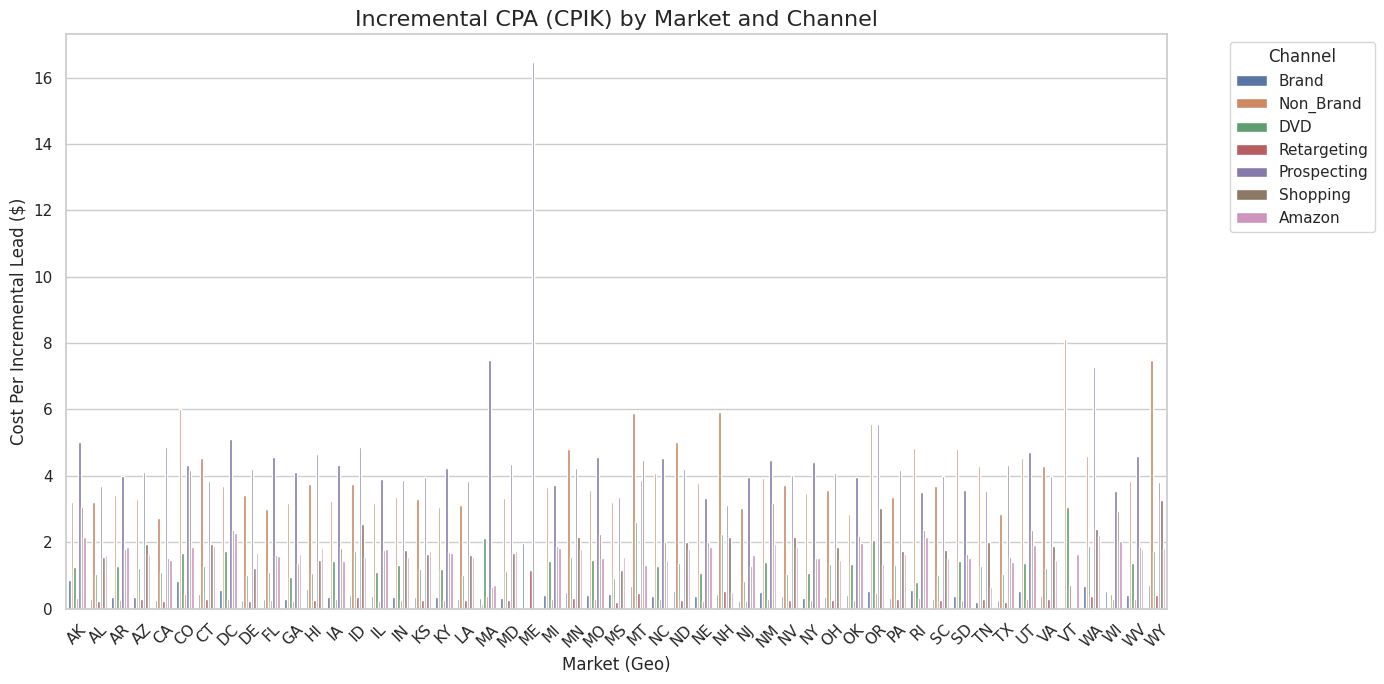

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the actual model results: Posterior Median
plot_df = geo_df[(geo_df['distribution'] == 'posterior') & (geo_df['metric'] == 'median') & (geo_df['channel'] != 'All Channels')].copy()


# Set plot style
sns.set_theme(style="whitegrid")

# --- PLOT 1: Incremental CPA by Market & Channel ---
plt.figure(figsize=(14, 7))
ax1 = sns.barplot(data=plot_df, x='geo', y='cpik', hue='channel')
plt.title('Incremental CPA (CPIK) by Market and Channel', fontsize=16)
plt.ylabel('Cost Per Incremental Lead ($)', fontsize=12)
plt.xlabel('Market (Geo)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [ ]:
pivot_df = plot_df.pivot(index='geo', columns='channel', values='incremental_outcome')

plt.figure(figsize=(14, 7))
pivot_df.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca())
plt.title('Total Incremental Lead Volume by Market', fontsize=16)
plt.ylabel('Incremental Leads', fontsize=12)
plt.xlabel('Market (Geo)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [ ]:
# --- PLOT 3: CPA Heatmap by Region (Efficiency View) ---
heatmap_data = plot_df.pivot(index='geo', columns='channel', values='cpik')

plt.figure(figsize=(10, 8))
# We remove cbar_kws to avoid the error and set it manually below
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu')

plt.title('CPL Heatmap: Efficiency by Region and Channel', fontsize=15)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Market (Geo)', fontsize=12)

# Set the colorbar label manually
cbar = ax.collections[0].colorbar
cbar.set_label('CPL ($)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Calculate shares within each specific Geo
geo_totals = plot_df.groupby('geo').agg({
    'spend': 'sum',
    'incremental_outcome': 'sum'
}).rename(columns={'spend': 'total_geo_spend', 'incremental_outcome': 'total_geo_incremental'})

geo_shares = plot_df.merge(geo_totals, on='geo')
geo_shares['Spend Share'] = (geo_shares['spend'] / geo_shares['total_geo_spend']) * 100
geo_shares['Effect Share'] = (geo_shares['incremental_outcome'] / geo_shares['total_geo_incremental']) * 100

melted_geo = geo_shares.melt(
    id_vars=['geo', 'channel'],
    value_vars=['Spend Share', 'Effect Share'],
    var_name='Metric',
    value_name='Percentage'
)

# 2. Create the faceted plot
g = sns.catplot(
    data=melted_geo, kind="bar",
    x="channel", y="Percentage", hue="Metric",
    col="geo", col_wrap=3,
    palette="viridis", height=5, aspect=1.3
)

g.set_axis_labels("Channel", "Share (%)")
g.set_titles("{col_name}", size=14)

# --- ADD LABELS AND ROTATION TO EVERY SUBPLOT ---
for ax in g.axes.flat:
    # Rotate Labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Label each bar in this subplot
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=9)

    # Increase y-limit slightly so labels don't hit the top of the box
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

plt.subplots_adjust(top=0.88, bottom=0.2, hspace=0.4)
g.fig.suptitle('Regional Spend vs. Effect Share', fontsize=18)
plt.show()

# FIX: Add extra space at the bottom for the rotated labels
plt.subplots_adjust(top=0.88, bottom=0.2)
g.fig.suptitle('Regional Spend vs. Effect Share', fontsize=18)
plt.show()

### Prospecting ↔ Organic Baseline Relationship

**Hypothesis:** If Prospecting primarily harvests existing demand (rather than creating it),
incremental Prospecting revenue should be *positively* correlated with organic baseline revenue —
high-demand periods are more responsive to the channel.
Alternatively, an *inverse* relationship would suggest Prospecting cannibalizes organic conversions
or that the holdout test’s low-demand timing biased the ROI prior downward.

Three views below test this:
1. **Dual-axis time series** — baseline revenue vs. Prospecting activity, with holdout and decline periods marked
2. **Scatter plot** — organic baseline vs. Prospecting incremental, colored by time tercile
3. **8-week rolling correlation** — whether the relationship is stable or seasonal

/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:1031: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:1031: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/russellwhealdon/mmm-workspace/.venv/lib/python3.11/site-packages/meridian/analysis/analyzer.py:34

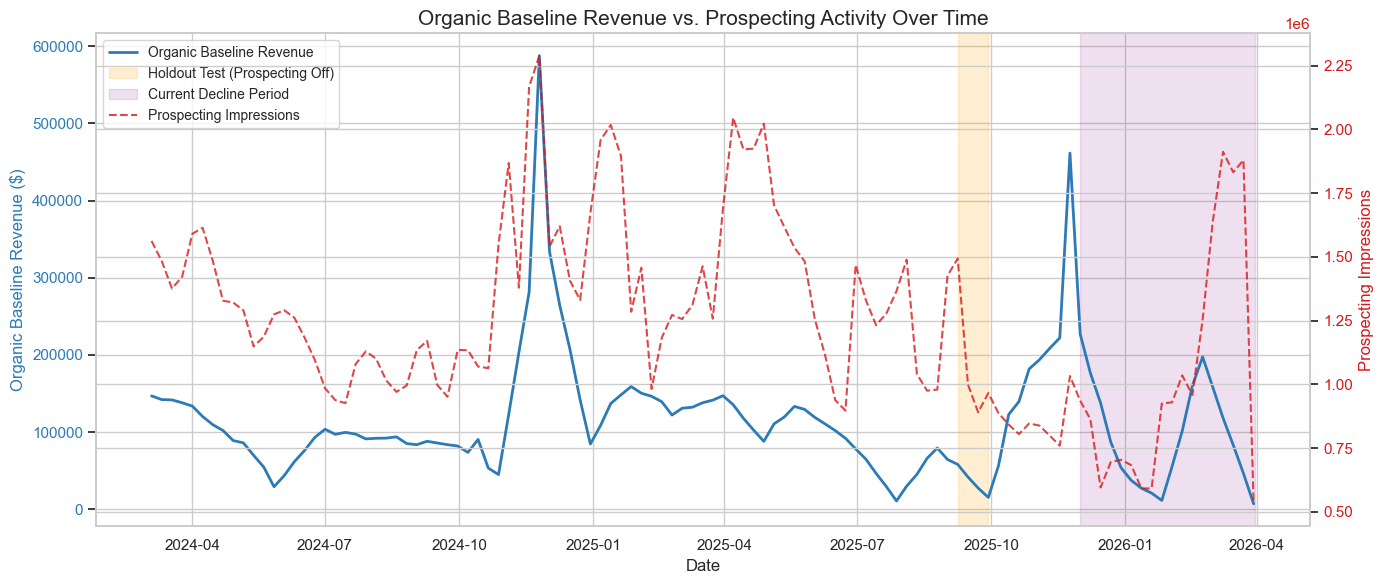

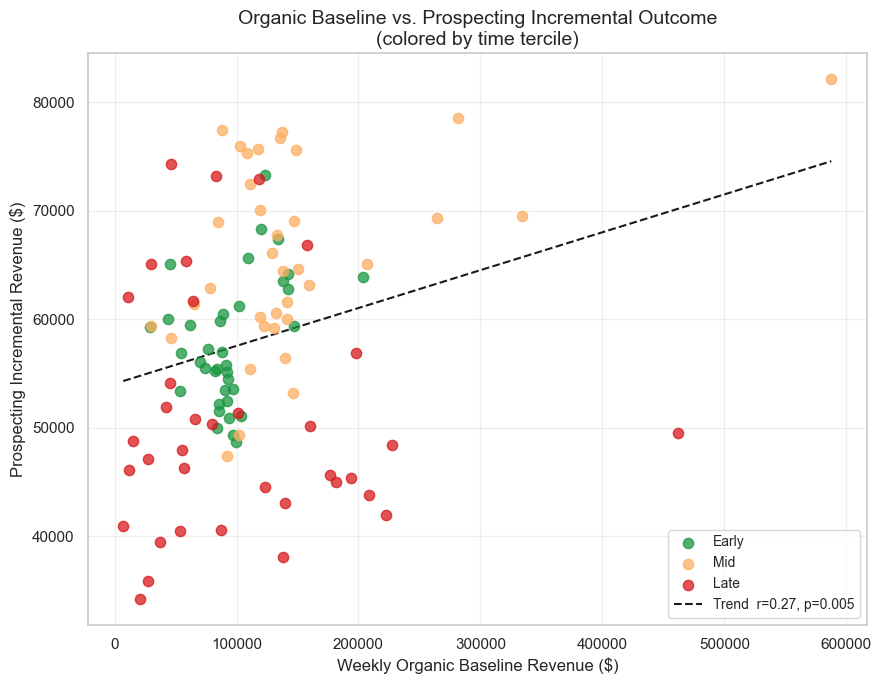

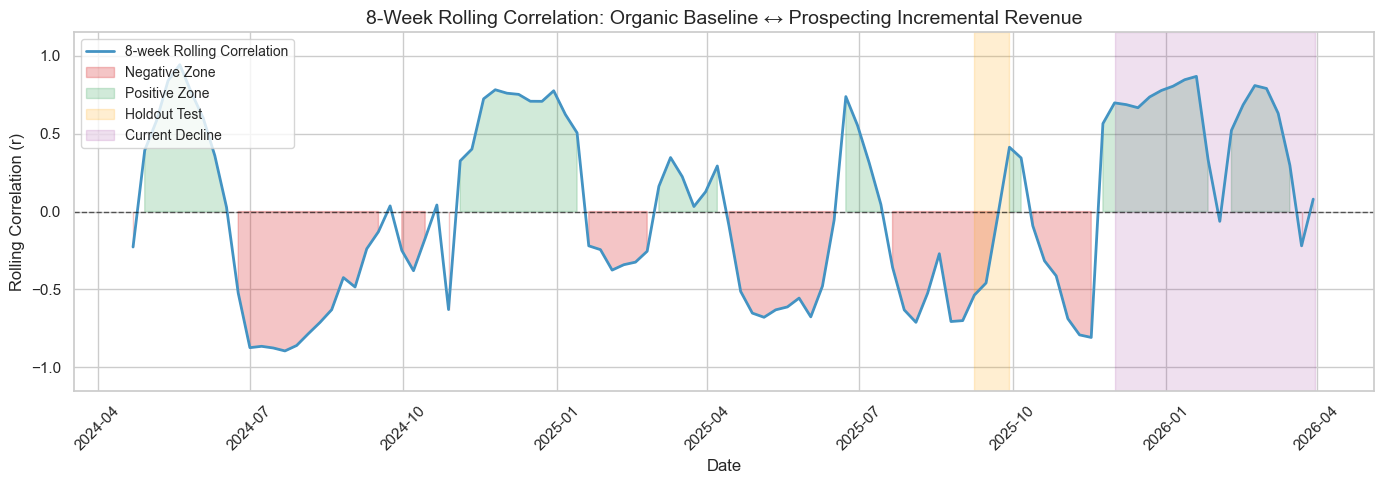

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# ── 1. EXTRACT TIME-SERIES DATA FROM MERIDIAN ────────────────────────────────

# Organic baseline over time
# (model prediction with ALL media set to zero — pure trend + controls)
eva = m_analyzer.expected_vs_actual_data(
    aggregate_geos=True,
    aggregate_times=False,
    use_kpi=True
)
baseline_dates = pd.to_datetime(eva.coords['time'].values)
baseline_mean  = eva['baseline'].sel(metric='mean').values.astype(float)

baseline_ts = pd.DataFrame({
    'date': baseline_dates,
    'baseline_revenue': baseline_mean
})

# Prospecting incremental outcome over time (posterior median)
ts_metrics = m_analyzer.summary_metrics(
    aggregate_geos=True,
    aggregate_times=False,
    use_kpi=True
)
ts_dates  = pd.to_datetime(ts_metrics.coords['time'].values)
prosp_inc = ts_metrics['incremental_outcome'].sel(
    channel='Prospecting',
    metric='median',
    distribution='posterior'
).values.astype(float)

prosp_ts = pd.DataFrame({'date': ts_dates, 'prosp_incremental': prosp_inc})

# Raw Prospecting impressions and spend, summed across geos per week
prosp_raw = (
    raw_data.groupby('date')
    .agg(
        prosp_impressions=('Prospecting_Impressions', 'sum'),
        prosp_cost=('Prospecting_Cost', 'sum')
    )
    .reset_index()
)
prosp_raw['date'] = pd.to_datetime(prosp_raw['date'])

# Master dataframe aligned on date
df = (
    baseline_ts
    .merge(prosp_ts,  on='date', how='inner')
    .merge(prosp_raw, on='date', how='left')
    .sort_values('date')
    .reset_index(drop=True)
)

# ── 2. KEY PERIOD DEFINITIONS ─────────────────────────────────────────────────
# Holdout: Prospecting was shut off (from roi_calibration_period comment in model spec)
HOLDOUT_START = pd.to_datetime('2025-09-08')
HOLDOUT_END   = pd.to_datetime('2025-09-29')

# Current decline period — adjust these dates based on observed baseline trend
DECLINE_START = pd.to_datetime('2025-12-01')
DECLINE_END   = pd.to_datetime('2026-03-31')

# ── CHART 1: DUAL-AXIS TIME SERIES ────────────────────────────────────────────
COLOR_BASELINE    = '#2C7BB6'
COLOR_PROSPECTING = '#D7191C'

sns.set_theme(style='whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df['date'], df['baseline_revenue'], color=COLOR_BASELINE, linewidth=2,
         label='Organic Baseline Revenue')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Organic Baseline Revenue ($)', color=COLOR_BASELINE, fontsize=12)
ax1.tick_params(axis='y', labelcolor=COLOR_BASELINE)

ax2 = ax1.twinx()
ax2.plot(df['date'], df['prosp_impressions'], color=COLOR_PROSPECTING,
         linewidth=1.5, alpha=0.8, linestyle='--', label='Prospecting Impressions')
ax2.set_ylabel('Prospecting Impressions', color=COLOR_PROSPECTING, fontsize=12)
ax2.tick_params(axis='y', labelcolor=COLOR_PROSPECTING)

ax1.axvspan(HOLDOUT_START, HOLDOUT_END, alpha=0.18, color='orange',
            label='Holdout Test (Prospecting Off)')
ax1.axvspan(DECLINE_START, DECLINE_END, alpha=0.12, color='purple',
            label='Current Decline Period')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Organic Baseline Revenue vs. Prospecting Activity Over Time', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── CHART 2: SCATTER — ORGANIC BASELINE vs. PROSPECTING INCREMENTAL ───────────
df['period'] = pd.cut(df.index, bins=3, labels=['Early', 'Mid', 'Late'])
period_colors = {'Early': '#1A9641', 'Mid': '#FDAE61', 'Late': '#D7191C'}

fig, ax = plt.subplots(figsize=(9, 7))

for period, grp in df.groupby('period', observed=True):
    ax.scatter(
        grp['baseline_revenue'], grp['prosp_incremental'],
        color=period_colors[str(period)], label=str(period),
        alpha=0.75, s=55, zorder=3
    )

# OLS trend line
valid = df[['baseline_revenue', 'prosp_incremental']].dropna()
slope, intercept, r_val, p_val, _ = stats.linregress(
    valid['baseline_revenue'], valid['prosp_incremental']
)
x_range = np.linspace(valid['baseline_revenue'].min(), valid['baseline_revenue'].max(), 100)
ax.plot(x_range, slope * x_range + intercept, 'k--', linewidth=1.5,
        label=f'Trend  r={r_val:.2f}, p={p_val:.3f}')

ax.set_xlabel('Weekly Organic Baseline Revenue ($)', fontsize=12)
ax.set_ylabel('Prospecting Incremental Revenue ($)', fontsize=12)
ax.set_title(
    'Organic Baseline vs. Prospecting Incremental Outcome\n(colored by time tercile)',
    fontsize=14
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── CHART 3: 8-WEEK ROLLING CORRELATION ───────────────────────────────────────
df_roll = df[['date', 'baseline_revenue', 'prosp_incremental']].dropna().copy()
df_roll['rolling_corr'] = (
    df_roll['baseline_revenue']
    .rolling(8)
    .corr(df_roll['prosp_incremental'])
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_roll['date'], df_roll['rolling_corr'],
        color='#4393C3', linewidth=2, label='8-week Rolling Correlation')
ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax.fill_between(
    df_roll['date'], df_roll['rolling_corr'], 0,
    where=(df_roll['rolling_corr'] < 0),
    alpha=0.25, color='#D7191C', label='Negative Zone'
)
ax.fill_between(
    df_roll['date'], df_roll['rolling_corr'], 0,
    where=(df_roll['rolling_corr'] >= 0),
    alpha=0.20, color='#1A9641', label='Positive Zone'
)

ax.axvspan(HOLDOUT_START, HOLDOUT_END, alpha=0.18, color='orange', label='Holdout Test')
ax.axvspan(DECLINE_START, DECLINE_END, alpha=0.12, color='purple', label='Current Decline')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Rolling Correlation (r)', fontsize=12)
ax.set_ylim(-1.15, 1.15)
ax.set_title(
    '8-Week Rolling Correlation: Organic Baseline ↔ Prospecting Incremental Revenue',
    fontsize=14
)
ax.legend(loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Budget Optimzer

In [ ]:
from meridian.analysis import optimizer

In [ ]:
# ==========================================================
# BUDGET OPTIMIZER (Meridian 1.4.0)
# ==========================================================
# Runs a fixed-budget optimization by default and returns an OptimizationResults object.

budget_optimizer = optimizer.BudgetOptimizer(mmm)

In [ ]:
# --- NATIONAL / ALL GEOS (default) ---
optimization_results = budget_optimizer.optimize(
    fixed_budget=True,                 # fixed total budget
    # Optional: restrict the optimization horizon (recommended: future-like window)
    # start_date="2025-01-06",
    # end_date="2025-03-31",
)

# View tables / plots
#optimization_results

# Optional: generate the optimizer HTML output (same pattern as model summary output)
optimization_results.output_optimization_summary("optimization_summary.html", "./")

IPython.display.HTML(filename="optimization_summary.html")

### Extract Real Model Outputs → outputs/northspore/

**Outputs are now written by `scripts/run_model.py`.**

Run from the repo root:
```bash
python scripts/run_model.py --client northspore --mode dev   # fast iteration
python scripts/run_model.py --client northspore --mode prod  # full production run
```

The script writes `contributions.csv`, `diagnostics.json`, and `status.json` to `outputs/northspore/`, and pushes the same data to BigQuery (`mmm.runs`, `mmm.diagnostics`, `mmm.contributions`) if `GOOGLE_APPLICATION_CREDENTIALS` is set.

Use this notebook for prior exploration, model spec iteration, and visual diagnostics only.